In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("cleaned_customer_shopping_behavior.csv")

shipping_summary = (
    df.groupby("shipping_type")
      .agg(
          customer_count=("shipping_type", "count"),
          average_spend=("purchase_amount_(usd)", "mean")
      )
      .reset_index()
)

In [65]:
shipping_summary["estimated_revenue"] = (
    shipping_summary["customer_count"]
    * shipping_summary["average_spend"]
)

shipping_summary

,shipping_type,customer_count,average_spend,estimated_revenue
0,2-Day Shipping,627,60.733652,38080.00
1,Express,931,62.460806,58151.01
2,Free Shipping,675,60.410370,40777.00
3,Next Day Air,648,58.631173,37993.00
4,Standard,920,60.737348,55878.36
5,Store Pickup,650,59.893846,38931.00


C:\Users\prasa\AppData\Local\Temp\ipykernel_40512\222969668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


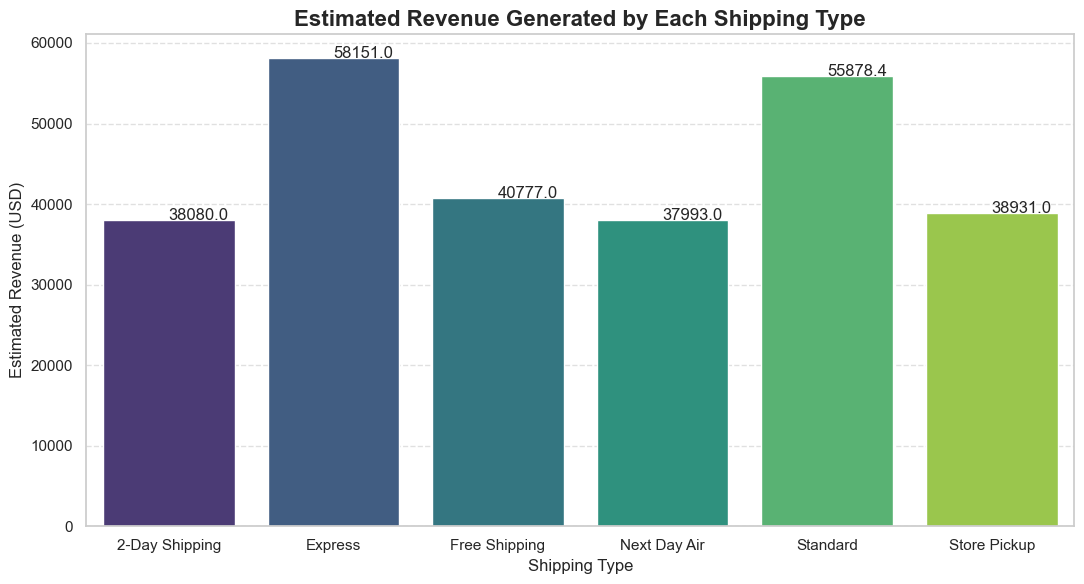

In [66]:
plt.figure(figsize=(11, 6))

sns.barplot(
    data=shipping_summary, x="shipping_type", y="estimated_revenue", palette="viridis"
)

plt.title(
    "Estimated Revenue Generated by Each Shipping Type", fontsize=16, weight="bold"
)
for index, row in shipping_summary.iterrows():
    plt.text(index, row.estimated_revenue, round(row.estimated_revenue, 1))

plt.xlabel("Shipping Type")
plt.ylabel("Estimated Revenue (USD)")

plt.grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

In [67]:
ranking = shipping_summary.sort_values(
    by="estimated_revenue",
    ascending=False
)

ranking

,shipping_type,customer_count,average_spend,estimated_revenue
1,Express,931,62.460806,58151.01
4,Standard,920,60.737348,55878.36
2,Free Shipping,675,60.410370,40777.00
5,Store Pickup,650,59.893846,38931.00
0,2-Day Shipping,627,60.733652,38080.00
3,Next Day Air,648,58.631173,37993.00


In [68]:
ranking["Rank"] = range(1, len(ranking) + 1)

ranking[["Rank", "shipping_type", "estimated_revenue"]]

,Rank,shipping_type,estimated_revenue
1,1,Express,58151.01
4,2,Standard,55878.36
2,3,Free Shipping,40777.00
5,4,Store Pickup,38931.00
0,5,2-Day Shipping,38080.00
3,6,Next Day Air,37993.00
